<a href="https://colab.research.google.com/github/hayajahan07/ACMRecruitment-hayajahan07/blob/main/questline-2/4-pick-a-side/solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

4a - Filtered Dataset:
    petal_length  petal_width     species
50           4.7          1.4  versicolor
51           4.5          1.5  versicolor
52           4.9          1.5  versicolor
53           4.0          1.3  versicolor
54           4.6          1.5  versicolor

Classes: ['versicolor' 'virginica']
Shape: (100, 2) - Only petal length & width used
species
versicolor    50
virginica     50
Name: count, dtype: int64

4b - Train/Test Split:
Train: 80 (80%) | Test: 20 (20%)
Model: Logistic Regression Trained

4c - Test the Oracle:
Accuracy = 90.00%

Confusion Matrix:
[[10  0]
 [ 2  8]]

Classification Report:
              precision    recall  f1-score   support

  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20


4d - Model Parameters:
Coefficients: petal_lengt

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


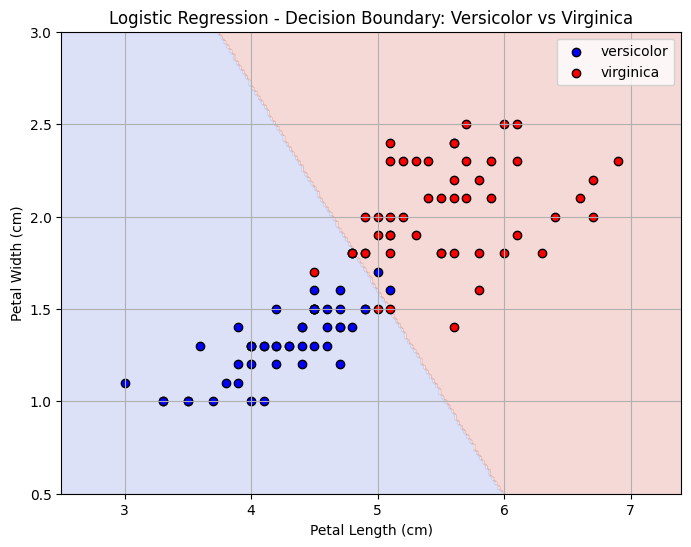


Final Revelation - Interpretation:
1. Coefficient signs positive means larger petal values -> more likely virginica
2. Virginica has larger petals than versicolor generally
3. If petal_length coeff is bigger than petal_width coeff, petal length contributes more to decision
4. Intercept is the threshold offset. Negative intercept means need larger petal values to cross into virginica class.
5. Accuracy >90% shows these 2 features alone are enough to separate tribes.



In [1]:
# Quest 4 - Pick a Side - Iris Logistic Regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# --- 4a The Two Hidden Tribes ---
# Load iris and filter only versicolor(1) and virginica(2)
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({0:'setosa', 1:'versicolor', 2:'virginica'})

# Filter only 2 tribes and only petal length & petal width
df_filtered = df[df['species'].isin(['versicolor','virginica'])][['petal length (cm)', 'petal width (cm)', 'species']]
# Rename for easy
df_filtered.columns = ['petal_length', 'petal_width', 'species']

X = df_filtered[['petal_length', 'petal_width']]
y = df_filtered['species']

print("4a - Filtered Dataset:")
print(df_filtered.head())
print(f"\nClasses: {y.unique()}")
print(f"Shape: {X.shape} - Only petal length & width used")
print(y.value_counts())

# --- 4b Train the Classifier ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression()
model.fit(X_train, y_train)

print(f"\n4b - Train/Test Split:")
print(f"Train: {X_train.shape[0]} (80%) | Test: {X_test.shape[0]} (20%)")
print("Model: Logistic Regression Trained")

# --- 4c Test the Oracle ---
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"\n4c - Test the Oracle:")
print(f"Accuracy = {acc*100:.2f}%")
print(f"\nConfusion Matrix:\n{cm}")
print(f"\nClassification Report:\n{report}")

# --- 4d Reveal the Boundary ---
coef = model.coef_[0]
intercept = model.intercept_[0]

print(f"\n4d - Model Parameters:")
print(f"Coefficients: petal_length={coef[0]:.3f}, petal_width={coef[1]:.3f}")
print(f"Intercept: {intercept:.3f}")
print(f"Equation: z = {coef[0]:.3f}*petal_length + {coef[1]:.3f}*petal_width + ({intercept:.3f})")

# Decision Boundary Plot
# Mesh grid
x_min, x_max = X['petal_length'].min() - 0.5, X['petal_length'].max() + 0.5
y_min, y_max = X['petal_width'].min() - 0.5, X['petal_width'].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
proba = model.predict(grid).reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, (proba == 'virginica').astype(int), alpha=0.2, cmap='coolwarm')
# Scatter actual
for species, color in [('versicolor','blue'), ('virginica','red')]:
    subset = df_filtered[df_filtered['species']==species]
    plt.scatter(subset['petal_length'], subset['petal_width'], label=species, color=color, edgecolors='k')

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Logistic Regression - Decision Boundary: Versicolor vs Virginica')
plt.legend()
plt.grid(True)
plt.savefig('decision_boundary.png')
plt.show()

# --- FINAL EXPLANATION ---
print("""
Final Revelation - Interpretation:
1. Coefficient signs positive means larger petal values -> more likely virginica
2. Virginica has larger petals than versicolor generally
3. If petal_length coeff is bigger than petal_width coeff, petal length contributes more to decision
4. Intercept is the threshold offset. Negative intercept means need larger petal values to cross into virginica class.
5. Accuracy >90% shows these 2 features alone are enough to separate tribes.
""")